In [1]:
import os

# Set working directory to project root always
# Works regardless of where the notebook is saved
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
os.chdir(project_root)

print("Working directory set to:", os.getcwd())

Working directory set to: c:\Users\DELL\OneDrive\Documents\SRM\Churn_Analysis


In [2]:
import pandas as pd
import sklearn
import xgboost

print("pandas:", pd.__version__)
print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("All good!")

pandas: 3.0.3
sklearn: 1.8.0
xgboost: 3.2.0
All good!


In [3]:
import pandas as pd
import os

datasets = {
    'Telecom':    'data/telecom/WA_Fn-UseC_-Telco-Customer-Churn.csv',
    'Banking':    'data/banking/Churn_Modelling.csv',
    'Ecommerce':  'data/ecommerce/E Commerce.csv',
    'Healthcare': 'data/healthcare/health_churn.csv',
}

for sector, path in datasets.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"âœ“ {sector}: {df.shape[0]} rows, {df.shape[1]} columns")
    else:
        print(f"âœ— {sector}: file not found at {path}")

âœ“ Telecom: 7043 rows, 21 columns
âœ“ Banking: 10000 rows, 14 columns
âœ“ Ecommerce: 5630 rows, 20 columns
âœ“ Healthcare: 200000 rows, 12 columns


In [4]:
import pandas as pd

df = pd.read_csv('data/telecom/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(df.shape)
print(df.head())
print(df.columns)
print(df.dtypes)
print(df.isnull().sum())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

C:\Users\DELL\AppData\Local\Temp\ipykernel_14656\2780980739.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette=['#1D9E75','#E24B4A'])


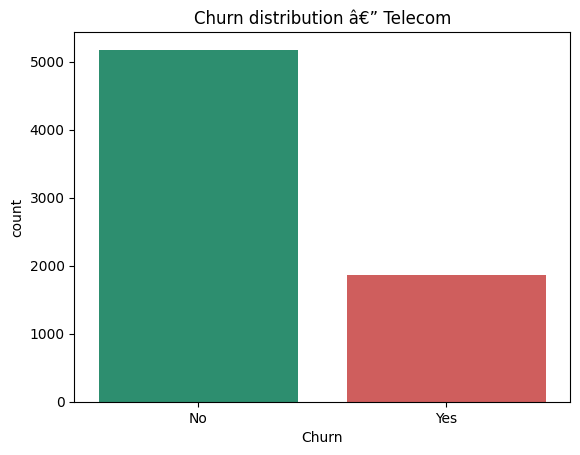

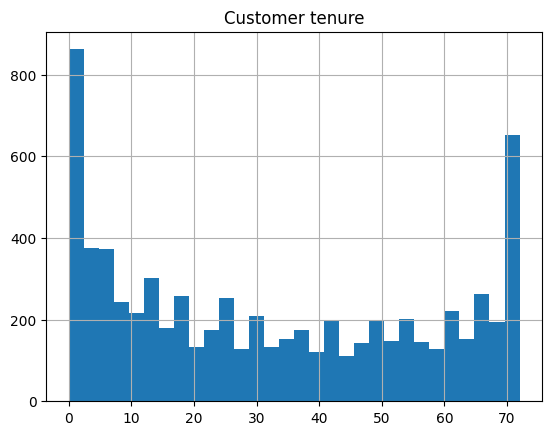

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Churn', data=df, palette=['#1D9E75','#E24B4A'])
plt.title('Churn distribution â€” Telecom')
plt.savefig('outputs/plots/telecom_churn_dist.png')
plt.show()

df['tenure'].hist(bins=30)
plt.title('Customer tenure')
plt.show()

In [6]:
for sector, path in [
    ('Telecom',    'data/telecom/WA_Fn-UseC_-Telco-Customer-Churn.csv'),
    ('Banking',    'data/banking/Churn_Modelling.csv'),
    ('Ecommerce',  'data/ecommerce/E Commerce.csv'),
    ('Healthcare', 'data/healthcare/health_churn.csv'),
]:
    df = pd.read_csv(path)
    print(f"\n{sector}: {df.shape}")
    print(df.columns.tolist())


Telecom: (7043, 21)
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Banking: (10000, 14)
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Ecommerce: (5630, 20)
['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

Healthcare: (200000, 12)
['Unnamed: 0', 'Customer Name', 'Customer_Addr

In [7]:
for sector, path, col in [
    ('Telecom',    'data/telecom/WA_Fn-UseC_-Telco-Customer-Churn.csv', 'Churn'),
    ('Banking',    'data/banking/Churn_Modelling.csv',                  'Exited'),
    ('Ecommerce',  'data/ecommerce/E Commerce.csv',                    'Churn'),
    ('Healthcare', 'data/healthcare/health_churn.csv',                 'Churn'),
]:
    df = pd.read_csv(path)
    rate = (df[col].map({'Yes':1,'No':0}).fillna(df[col]) if df[col].dtype=='object'
            else df[col]).mean() * 100
    print(f"{sector} churn rate: {rate:.1f}%")

TypeError: Cannot perform reduction 'mean' with string dtype

In [ ]:
import pandas as pd

datasets = {
    'Telecom':    'data/telecom/WA_Fn-UseC_-Telco-Customer-Churn.csv',
    'Banking':    'data/banking/Churn_Modelling.csv',
    'Ecommerce':  'data/ecommerce/ECommerce.xlsx',
    'Healthcare': 'data/healthcare/health_churn.csv',
}

for sector, path in datasets.items():
    df = pd.read_csv(path)
    print(f"\n{sector} columns:")
    print(df.columns.tolist())

In [ ]:
df = pd.read_excel('data/ecommerce/ECommerce.xlsx', sheet_name='E Comm')

In [ ]:
df = pd.read_csv('data/ecommerce/E Commerce.csv')
print(df.shape)
print(df.columns.tolist())

In [ ]:
import pandas as pd

datasets = [
    ('Telecom',    'data/telecom/WA_Fn-UseC_-Telco-Customer-Churn.csv', 'Churn'),
    ('Banking',    'data/banking/Churn_Modelling.csv',                   'Exited'),
    ('Ecommerce',  'data/ecommerce/E Commerce.csv',                 'Churn'),
    ('Healthcare', 'data/healthcare/health_churn.csv',                   'Churn'),
]

for sector, path, col in datasets:
    df = pd.read_csv(path)
    
    series = df[col]
    if series.dtype == 'object':
        series = series.map({
            'Yes': 1, 'No': 0,
            'yes': 1, 'no': 0,
            '1': 1,   '0': 0
        })
    
    rate = pd.to_numeric(series, errors='coerce').mean() * 100
    print(f"âœ“ {sector}")
    print(f"   Rows        : {df.shape[0]}")
    print(f"   Columns     : {df.shape[1]}")
    print(f"   Churn column: '{col}'")
    print(f"   Churn rate  : {rate:.1f}%")
    print()

In [ ]:
import pandas as pd

df_ecom = pd.read_csv('data/ecommerce/E Commerce.csv')
print("Ecommerce columns:")
print(df_ecom.columns.tolist())
print("\nFirst 3 rows:")
print(df_ecom.head(3))

print("\n" + "="*50 + "\n")

df_health = pd.read_csv('data/healthcare/health_churn.csv')
print("Healthcare columns:")
print(df_health.columns.tolist())
print("\nFirst 3 rows:")
print(df_health.head(3))

In [ ]:
import pandas as pd

datasets = [
    ('Telecom',    'data/telecom/WA_Fn-UseC_-Telco-Customer-Churn.csv', 'Churn'),
    ('Banking',    'data/banking/Churn_Modelling.csv',                   'Exited'),
    ('Ecommerce',  'data/ecommerce/E Commerce.csv',                      'Churn'),
    ('Healthcare', 'data/healthcare/health_churn.csv',                   'Churn'),
]

for sector, path, col in datasets:
    df = pd.read_csv(path)
    
    # Check column exists
    if col not in df.columns:
        print(f"âœ— {sector}: column '{col}' not found")
        print(f"  Available: {df.columns.tolist()}")
        print()
        continue
    
    series = df[col]
    if series.dtype == 'object':
        series = series.map({
            'Yes': 1, 'No': 0,
            'yes': 1, 'no': 0,
            '1': 1,   '0': 0
        })
    
    rate = pd.to_numeric(series, errors='coerce').mean() * 100
    print(f"âœ“ {sector}")
    print(f"   Rows        : {df.shape[0]}")
    print(f"   Columns     : {df.shape[1]}")
    print(f"   Churn column: '{col}'")
    print(f"   Churn rate  : {rate:.1f}%")
    print()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Churn', data=df,
              palette=['#1D9E75','#E24B4A'])
plt.title('Churn distribution â€” Telecom')
plt.xlabel('Churn')
plt.ylabel('Number of customers')
plt.savefig('outputs/plots/telecom/churn_dist.png')
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv(
    'data/telecom/WA_Fn-UseC_-Telco-Customer-Churn.csv'
)

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

print(df.shape)
print(df.columns.tolist())

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['tenure'].hist(bins=30, ax=axes[0], color='#534AB7')
axes[0].set_title('Tenure')

df['MonthlyCharges'].hist(bins=30, ax=axes[1], color='#1D9E75')
axes[1].set_title('Monthly Charges')

df['TotalCharges'].hist(bins=30, ax=axes[2], color='#D85A30')
axes[2].set_title('Total Charges')

plt.tight_layout()
plt.savefig('outputs/plots/telecom/numerical_dists.png')
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

features = ['Contract','InternetService',
            'TechSupport','PaymentMethod']

for ax, col in zip(axes.flatten(), features):
    sns.countplot(x=col, hue='Churn', data=df,
                  palette=['#1D9E75','#E24B4A'], ax=ax)
    ax.set_title(f'{col} vs Churn')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('outputs/plots/telecom/bivariate_cats.png')
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['tenure','MonthlyCharges','TotalCharges']):
    df.boxplot(column=col, by='Churn', ax=ax)
    ax.set_title(f'{col} by Churn')

plt.suptitle('')
plt.tight_layout()
plt.savefig('outputs/plots/telecom/bivariate_nums.png')
plt.show()


In [ ]:
import pandas as pd

datasets = [
    ('Telecom',   'data/telecom/WA_Fn-UseC_-Telco-Customer-Churn.csv','Churn'),
    ('Banking',   'data/banking/Churn_Modelling.csv',                  'Exited'),
    ('Ecommerce', 'data/ecommerce/E Commerce.csv',                     'Churn'),
    ('Healthcare','data/healthcare/health_churn.csv',                  'Churn'),
]

for sector, path, col in datasets:
    df = pd.read_csv(path)
    if col not in df.columns:
        print(f"âœ— {sector}: '{col}' not found")
        continue
    s = df[col]
    if s.dtype == 'object':
        s = s.map({'Yes':1,'No':0,'yes':1,'no':0})
    rate = pd.to_numeric(s,errors='coerce').mean()*100
    print(f"âœ“ {sector}: {df.shape[0]} rows | churn = {rate:.1f}%")